In [9]:
import sys
import os

# Define the project root directory
# Assuming your notebook is in 'd:\Long Hair Identification\notebook'
# We need to go up one level from 'notebook' to reach 'Long Hair Identification'
project_root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), os.pardir))
# A more direct way assuming 'Long Hair Identification' is the root
project_root = "d:\\Long Hair Identification" # Or derive it dynamically from __file__ if running a script

# Ensure the project root is in sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Insert at the beginning to prioritize your modules

print("Updated Python search path (sys.path):")
for p in sys.path:
    print(f"- {p}")

# Now, your import should work
from utils.dataset_loader import load_utkface_images

# Rest of your code
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Module 'utils.dataset_loader' imported successfully!")

Updated Python search path (sys.path):
- d:\Long Hair Identification
- C:\Program Files\Python312\python312.zip
- C:\Program Files\Python312\DLLs
- C:\Program Files\Python312\Lib
- C:\Program Files\Python312
- d:\Long Hair Identification\venv
- 
- d:\Long Hair Identification\venv\Lib\site-packages
- d:\Long Hair Identification\venv\Lib\site-packages\win32
- d:\Long Hair Identification\venv\Lib\site-packages\win32\lib
- d:\Long Hair Identification\venv\Lib\site-packages\Pythonwin
Module 'utils.dataset_loader' imported successfully!


In [10]:
data_dir = r'D:\Long Hair Identification\dataset\long_Hair_dataset\UTKFace'

images, ages, genders = load_utkface_images(data_dir)

print(f"Images loaded: {images.shape}")
print(f"Ages loaded: {ages.shape}")
print(f"Genders loaded: {genders.shape}")


Images loaded: (4869, 128, 128, 3)
Ages loaded: (4869,)
Genders loaded: (4869,)


In [11]:
def label_age_class(age):
    if age < 20:
        return 0
    elif 20 <= age <= 30:
        return 1
    else:
        return 2

age_classes = np.array([label_age_class(age) for age in ages])


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images, age_classes, test_size=0.2, random_state=42, stratify=age_classes
)


In [13]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')   # 3 Age Classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,139 (6.48 MB)

 Trainable params: 1,699,139 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,   # You can increase epochs
    batch_size=32
)


Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 43s 322ms/step - accuracy: 0.5670 - loss: 0.7026 - val_accuracy: 0.7495 - val_loss: 0.5100
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 37s 307ms/step - accuracy: 0.7814 - loss: 0.4712 - val_accuracy: 0.7731 - val_loss: 0.4836
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 40s 326ms/step - accuracy: 0.7994 - loss: 0.4356 - val_accuracy: 0.7895 - val_loss: 0.4430
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 311ms/step - accuracy: 0.8135 - loss: 0.3981 - val_accuracy: 0.7906 - val_loss: 0.4346
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 308ms/step - accuracy: 0.8363 - loss: 0.3620 - val_accuracy: 0.7936 - val_loss: 0.4163
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 309ms/step - accuracy: 0.8515 - loss: 0.3269 - val_accuracy: 0.7977 - val_loss: 0.4284
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 312ms/step - accuracy: 0.8610 - loss: 0.3127 - val_accuracy: 0.8131 - val_loss: 0.4051
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 313ms/step - accuracy: 0.8689 - loss: 0

In [15]:
model.save('../models/age_model.h5')
print("Age model saved successfully.")


Age model saved successfully.


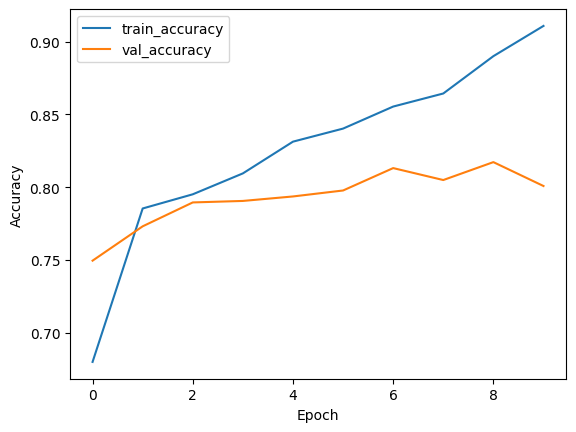

In [16]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

